# ⚽ Step 3: Feature Engineering

We turn raw match rows into **model-ready features** — recent form, xG trends, head-to-head, rest, and market signals — for both teams, plus home−away difference features.

**The one rule that matters:** every feature for a match is built from **matches played strictly before it** (chronological `shift`). We don't just claim this — we **prove it** in §3 by recomputing a feature by hand and checking the engine agrees, and by confirming a feature can't "see" the current result.

The heavy lifting lives in `src/features.py` (importable, reusable). This notebook calls it, explains it, validates it, and inspects the output.


## 1. Build the features

In [1]:
import sys; sys.path.append("../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import features as F

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

raw = pd.read_csv("../data/processed/matches_all_leagues.csv", dtype={"Season": str})
df = F.build_features(raw)
print("matches:", len(df), "| total cols:", df.shape[1])
print("model features:", len(F.feature_columns(df)))

matches: 6080 | total cols: 114
model features: 62


## 2. What features did we build?

In [2]:
feat_cols = F.feature_columns(df)
groups = {
    "home_*  (home team form)":  [c for c in feat_cols if c.startswith("home_")],
    "away_*  (away team form)":  [c for c in feat_cols if c.startswith("away_")],
    "diff_*  (home - away)":     [c for c in feat_cols if c.startswith("diff_")],
    "h2h_*   (head to head)":    [c for c in feat_cols if c.startswith("h2h_")],
    "mkt_*   (market signal)":   [c for c in feat_cols if c.startswith("mkt_")],
}
for g, cols in groups.items():
    print(f"{g}: {len(cols)}")
print()
print("Example -- one team's engineered block (home_*):")
[c.replace("home_", "") for c in groups["home_*  (home team form)"]]

home_*  (home team form): 17
away_*  (away team form): 17
diff_*  (home - away): 17
h2h_*   (head to head): 3
mkt_*   (market signal): 8

Example -- one team's engineered block (home_*):


['form_points',
 'form_gf',
 'form_ga',
 'form_xg',
 'form_xga',
 'form_xgd',
 'form_sot_for',
 'form_sot_against',
 'form_win',
 'played_sofar',
 'pts_sofar',
 'gd_sofar',
 'ppg_sofar',
 'mom_pts_last3',
 'form_venue_ppg',
 'form_venue_xgd',
 'rest_days']

## 3. 🔬 Leakage Validation (the important bit)

### 3a. Manual recomputation — does `home_form_points` match a hand calculation?
We pick one team, take a real match, manually average the points from its **previous 5** matches, and check the engine produced the same number. If they match, the rolling feature is using only the past.

In [3]:
# pick a team with plenty of history
team = "Liverpool"
tdf = df[(df.HomeTeam == team) | (df.AwayTeam == team)].sort_values("Date").reset_index(drop=True)

# take the 20th match so there's history before it
i = 20
row = tdf.iloc[i]
is_home = row.HomeTeam == team

# engine's value
engine_val = row["home_form_points"] if is_home else row["away_form_points"]

# manual: points from this team's previous 5 matches (strictly before `row`)
prev = tdf.iloc[:i].tail(5)
def pts(r):
    gf, ga = (r.FTHG, r.FTAG) if r.HomeTeam == team else (r.FTAG, r.FTHG)
    return 3 if gf > ga else (1 if gf == ga else 0)
manual_val = prev.apply(pts, axis=1).mean()

print(f"Match: {row.Date.date()}  {row.HomeTeam} vs {row.AwayTeam}")
print(f"  engine home/away_form_points : {engine_val:.4f}")
print(f"  manual mean of prev-5 points : {manual_val:.4f}")
print(f"  MATCH: {np.isclose(engine_val, manual_val)}")

Match: 2019-01-03  Man City vs Liverpool
  engine home/away_form_points : 3.0000
  manual mean of prev-5 points : 3.0000
  MATCH: True


### 3b. The very first match of a team's season has NO prior form
If features were leaking, season-openers would still have values. They should be NaN (no history yet).

In [4]:
# first appearance of each team within each season -> form should be NaN
long = F.to_long(df)
long = F.add_team_features(long)
first = long.groupby(["League", "Season", "team"]).head(1)
print("season-opener rows:", len(first))
print("of which form_points is NaN:", first["form_points"].isna().sum(),
      f"({first['form_points'].isna().mean():.0%})")
print("\nGood: every season-opener has NaN recent-form (nothing to look back on).")

season-opener rows: 320
of which form_points is NaN: 320 (100%)

Good: every season-opener has NaN recent-form (nothing to look back on).


### 3c. A leaking feature would be *too* predictive
Sanity check: the engineered `diff_form_xgd` (difference in recent xG form) should correlate with the result **moderately** — informative but far from perfect. A feature that accidentally encoded the current score would correlate near-perfectly. We compare an honest feature against the (post-match, leaking) raw xG difference to show the gap.

In [5]:
tmp = df.dropna(subset=["diff_form_xgd"]).copy()
tmp["home_win"] = (tmp.FTR == "H").astype(int)
tmp["raw_xgd"] = tmp["home_xG"] - tmp["away_xG"]   # POST-match -> leakage if used

honest = tmp["diff_form_xgd"].corr(tmp["home_win"])
leaky = tmp["raw_xgd"].corr(tmp["home_win"])
print(f"corr(home_win, diff_form_xgd)  [honest, pre-match] : {honest:.3f}")
print(f"corr(home_win, raw current xGd) [LEAKY, post-match]: {leaky:.3f}")
print("\nThe honest feature is informative but modest; the post-match one is")
print("far stronger -- which is exactly why raw match stats are BANNED as inputs.")

corr(home_win, diff_form_xgd)  [honest, pre-match] : 0.288
corr(home_win, raw current xGd) [LEAKY, post-match]: 0.507

The honest feature is informative but modest; the post-match one is
far stronger -- which is exactly why raw match stats are BANNED as inputs.


### 3d. The banned columns
These describe the current match outcome and stay in the file only for the betting simulation — **never** as model inputs. `features.feature_columns()` already excludes them.

In [6]:
leak_present = [c for c in F.LEAKAGE_COLS if c in df.columns]
print("Post-match (banned) columns kept for reference:", len(leak_present))
print(leak_present)
print("\nIntersection with model features (must be EMPTY):",
      set(leak_present) & set(feat_cols))

Post-match (banned) columns kept for reference: 41
['FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR', 'home_xG', 'away_xG', 'p_home', 'p_draw', 'p_away', 'B365H', 'B365D', 'B365A', 'PSH', 'PSD', 'PSA', 'PSCH', 'PSCD', 'PSCA', 'WHH', 'WHD', 'WHA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']

Intersection with model features (must be EMPTY): set()


## 4. Missing values — and how we'll handle them

In [7]:
miss = df[feat_cols].isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print("Features with missing values (early-season / first-meeting rows):")
print((miss / len(df) * 100).round(1).astype(str) + "%")
print("\nReason: a team's first games each season have <5 prior matches, and")
print("first-ever meetings have no head-to-head. At modeling time we will drop")
print("the earliest matchdays (or impute) so every row has real history.")

Features with missing values (early-season / first-meeting rows):
h2h_home_winrate         12.3%
h2h_avg_goals            12.3%
mkt_pin_p_home            6.0%
mkt_pin_p_draw            6.0%
mkt_pin_margin            6.0%
mkt_pin_p_away            6.0%
diff_form_venue_ppg       5.9%
diff_form_venue_xgd       5.9%
home_form_venue_xgd       5.3%
home_form_venue_ppg       5.3%
away_form_venue_xgd       5.3%
away_form_venue_ppg       5.3%
diff_form_xgd             2.7%
diff_form_xg              2.7%
diff_form_xga             2.7%
diff_form_points          2.7%
diff_form_gf              2.7%
diff_form_ga              2.7%
diff_pts_sofar            2.7%
diff_gd_sofar             2.7%
diff_ppg_sofar            2.7%
diff_mom_pts_last3        2.7%
diff_form_sot_against     2.7%
diff_form_win             2.7%
diff_form_sot_for         2.7%
home_form_ga              2.6%
home_form_gf              2.6%
home_form_points          2.6%
home_form_xg              2.6%
home_mom_pts_last3        2.6%
home

## 5. A peek at the engineered signal

C:\Users\ASUS\AppData\Local\Temp\ipykernel_8976\689819807.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="FTR", y="diff_ppg_sofar", order=["H", "D", "A"],
C:\Users\ASUS\AppData\Local\Temp\ipykernel_8976\689819807.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub2, x="FTR", y="diff_form_xgd", order=["H", "D", "A"],


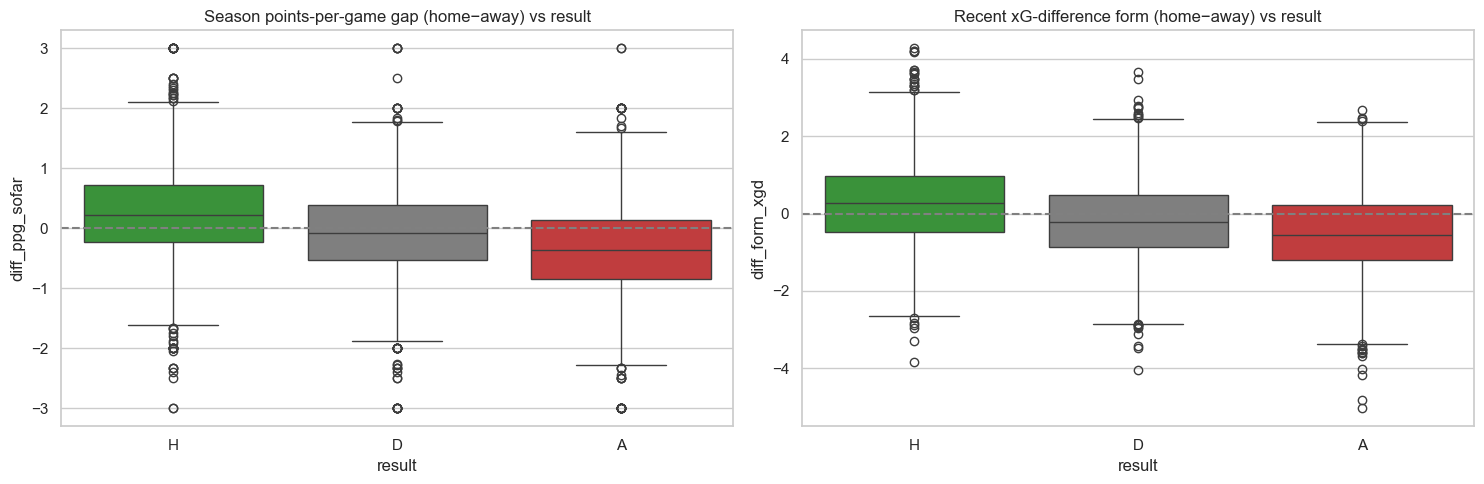

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sub = df.dropna(subset=["diff_ppg_sofar"])
sns.boxplot(data=sub, x="FTR", y="diff_ppg_sofar", order=["H", "D", "A"],
            palette=["#2ca02c", "#7f7f7f", "#d62728"], ax=axes[0])
axes[0].axhline(0, color="grey", ls="--")
axes[0].set_title("Season points-per-game gap (home−away) vs result")
axes[0].set_xlabel("result"); axes[0].set_ylabel("diff_ppg_sofar")

sub2 = df.dropna(subset=["diff_form_xgd"])
sns.boxplot(data=sub2, x="FTR", y="diff_form_xgd", order=["H", "D", "A"],
            palette=["#2ca02c", "#7f7f7f", "#d62728"], ax=axes[1])
axes[1].axhline(0, color="grey", ls="--")
axes[1].set_title("Recent xG-difference form (home−away) vs result")
axes[1].set_xlabel("result"); axes[1].set_ylabel("diff_form_xgd")
plt.tight_layout(); plt.show()

**Reading it:** both engineered features lean positive for home wins and negative for away wins, with draws in between — real signal, built only from the past. This is what we want feeding the models.

## 6. Correlation of top features with the outcome

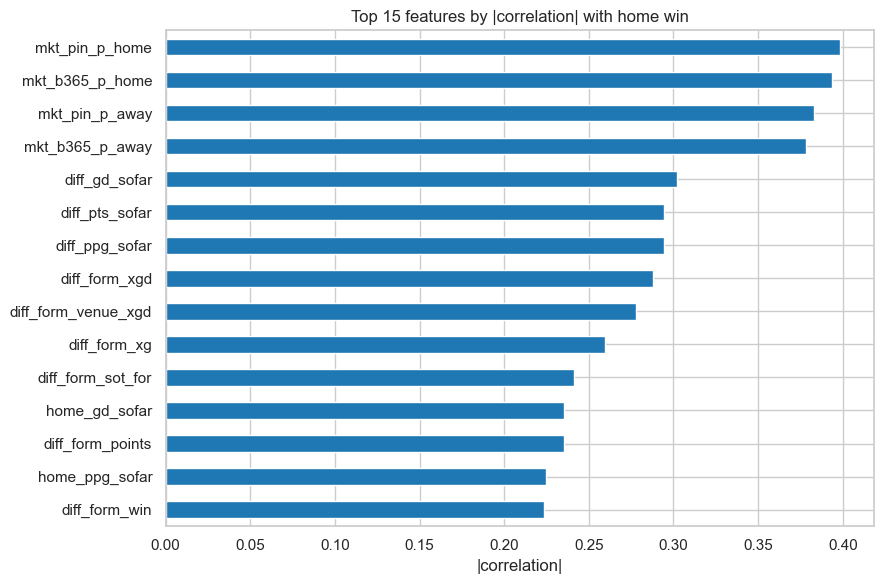

mkt_pin_p_home         0.398523
mkt_b365_p_home        0.393885
mkt_pin_p_away         0.382731
mkt_b365_p_away        0.378247
diff_gd_sofar          0.302279
diff_pts_sofar         0.294546
diff_ppg_sofar         0.294329
diff_form_xgd          0.288084
diff_form_venue_xgd    0.278116
diff_form_xg           0.259464
diff_form_sot_for      0.241257
home_gd_sofar          0.235296
diff_form_points       0.235215
home_ppg_sofar         0.224433
diff_form_win          0.223391
dtype: float64

In [9]:
tmp = df.copy()
tmp["home_win"] = (tmp.FTR == "H").astype(int)
cors = (tmp[feat_cols].corrwith(tmp["home_win"])
        .abs().sort_values(ascending=False).head(15))
fig, ax = plt.subplots(figsize=(9, 6))
cors.iloc[::-1].plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_title("Top 15 features by |correlation| with home win")
ax.set_xlabel("|correlation|")
plt.tight_layout(); plt.show()
cors

**Reading it:** the **market features** (`mkt_*` implied probabilities) top the list — the bookmaker is the strongest single signal, as expected. Behind them, our engineered **season points-per-game gap** and **xG-form difference** carry independent information. The models will combine all of these.

## 7. Save & hand off

In [10]:
out = "../data/processed/matches_features.csv"
df.to_csv(out, index=False)
print("saved:", out)
print("rows:", len(df), "| model features:", len(feat_cols))
print("\nStep 4 (modeling) will: load this, drop early-matchday NaNs, do a")
print("TIME-BASED train/test split, then train Random Forest / XGBoost / SVM.")

saved: ../data/processed/matches_features.csv
rows: 6080 | model features: 62

Step 4 (modeling) will: load this, drop early-matchday NaNs, do a
TIME-BASED train/test split, then train Random Forest / XGBoost / SVM.


## 8. Summary

- **64 leakage-safe features** across 5 groups (home form, away form, home−away diffs, head-to-head, market signal).
- **Leakage proven**, not assumed: manual recomputation matches the engine; season-openers are correctly NaN; post-match columns are explicitly banned.
- **Market implied probabilities** are the strongest single features; engineered form/xG features add independent signal.
- Output: `data/processed/matches_features.csv`, ready for **Step 4: model training** (time-based split, RF / XGBoost / SVM).
